In [2]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
# Then your other imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input, GaussianNoise
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam
from keras import regularizers
import optuna
import shap

In [3]:
# For reproducibility add the same seed. "42" is the standard value.
random_number_seed = 42
np.random.seed(random_number_seed)
keras.utils.set_random_seed(random_number_seed)

#### Help functions

In [4]:
# Function that plots the training and validation for the different epochs.
from matplotlib import legend


def training_validation_history_plot(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.set_theme(style="ticks")
    # Loss plot
    axes[0].plot(history.history['loss'], label='Training Loss')
    axes[0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0].set_xlabel('Epoch', fontsize=16)
    axes[0].set_ylabel('Loss (MSE)', fontsize=16)
    # axes[0].set_title('Model Loss')
    axes[0].grid(True, axis="both", linewidth=0.6, color="black", alpha=0.3)
    axes[0].tick_params(axis='both', labelsize=16)
    legend = axes[0].legend(
        facecolor='white',      # Solid white background
        edgecolor='black',      # Black border
        framealpha=1,           # Fully opaque
        fancybox=True,          # Rounding of the box
)
    legend.get_frame().set_linewidth(0.4) # Changing the thickness of the border
    
    # MAE plot
    axes[1].plot(history.history['mae'], label='Training MAE')
    axes[1].plot(history.history['val_mae'], label='Validation MAE')
    axes[1].set_xlabel('Epoch', fontsize=16)
    axes[1].set_ylabel('MAE', fontsize=16)
    # axes[1].set_title('Model MAE')
    axes[1].grid(True, axis="both", linewidth=0.6, color="black", alpha=0.3)
    axes[1].tick_params(axis='both', labelsize=16)
    legend = axes[1].legend(
        facecolor='white',      # Solid white background
        edgecolor='black',      # Black border
        framealpha=1,           # Fully opaque
        fancybox=True,          # Rounding of the box
)
    legend.get_frame().set_linewidth(0.4) # Changing the thickness of the border
    
    plt.tight_layout()
    plt.show() 

# Performance metrics on the training set
def performance_metrics(Y_train, Y_train_pred, Y_test, Y_test_pred):
    mse_train  = mean_squared_error(Y_train, Y_train_pred)
    rmse_train = np.sqrt(mse_train)
    mae_train  = np.mean(np.abs(Y_train - Y_train_pred))
    r2_train   = r2_score(Y_train, Y_train_pred)
    
    print(f"\nPerformance metrics on the training set:")
    print(f"R² Score: {r2_train:.4f}")
    print(f"MSE:      {mse_train:.2f}")
    print(f"RMSE:     {rmse_train:.2f}%")
    print(f"MAE:      {mae_train:.2f}%")
    
    # Performance metrics on testing set
    mse_test  = mean_squared_error(Y_test, Y_test_pred)
    rmse_test = np.sqrt(mse_test)
    mae_test  = np.mean(np.abs(Y_test - Y_test_pred))
    r2_test   = r2_score(Y_test, Y_test_pred)
    
    print(f"\nPerformance metrics on testing set:")
    print(f"R² Score: {r2_test:.4f}")
    print(f"MSE:      {mse_test:.2f}")
    print(f"RMSE:     {rmse_test:.2f}%")
    print(f"MAE:      {mae_test:.2f}%")

    return mse_train, rmse_train, mae_train, r2_train, mse_test, rmse_test, mae_test, r2_test

def parity_plot(Y_train, Y_train_pred, Y_test, Y_test_pred):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.set_theme(style="ticks")

    # Calculate the metrics
    r2_test   = r2_score(Y_test, Y_test_pred)
    rmse_test = np.sqrt(mean_squared_error(Y_test, Y_test_pred))
    mae_test  = np.mean(np.abs(Y_test - Y_test_pred))
    r2_train  = r2_score(Y_train, Y_train_pred)
    rmse_train = np.sqrt(mean_squared_error(Y_train, Y_train_pred))
    mae_train  = np.mean(np.abs(Y_train - Y_train_pred))
    
    # Test set parity plot
    axes[0].scatter(Y_test, Y_test_pred, alpha=0.6, edgecolors='black', linewidth=0.5)
    min_val = -5
    max_val = 105
    axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal Prediction')
    axes[0].fill_between([min_val, max_val],
                         [min_val - 10, max_val - 10],
                         [min_val + 10, max_val + 10],
                         alpha=0.2, color='gray', label='±10% Error')
    
    # Create combined legend entry for metrics
    test_metrics_label = f'R² = {r2_test:.3f}\nRMSE = {rmse_test:.2f}%\nMAE = {mae_test:.2f}%'
    
    axes[0].set_xlabel('Experimental Yield (%)', fontsize=16)
    axes[0].set_ylabel('Predicted Yield (%)', fontsize=16)
    axes[0].grid(True, axis="both", linewidth=0.6, color="black", alpha=0.3)
    axes[0].tick_params(axis='both', labelsize=16)
    
    # Create legend with metrics included
    legend = axes[0].legend(
        handles=[
            plt.Line2D([0], [0], color='r', linestyle='--', linewidth=2, label='Ideal Prediction'),
            plt.Rectangle((0,0),1,1, facecolor='gray', alpha=0.2, label='±10% Error'),
            plt.Line2D([0], [0], color='none', label=test_metrics_label)
        ],
        facecolor='white',
        edgecolor='black',
        framealpha=1,
        fancybox=True,
        loc='best'
    )
    legend.get_frame().set_linewidth(0.4)
    
    axes[0].set_xlim(-5, 105)
    axes[0].set_ylim(-5, 105)
    
    # Training set parity plot
    axes[1].scatter(Y_train, Y_train_pred, alpha=0.6, edgecolors='black', linewidth=0.5)
    min_val = -5
    max_val = 105
    axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal Prediction')
    axes[1].fill_between([min_val, max_val],
                         [min_val - 10, max_val - 10],
                         [min_val + 10, max_val + 10],
                         alpha=0.2, color='gray', label='±10% Error')
    
    # Create combined legend entry for metrics
    train_metrics_label = f'R² = {r2_train:.3f}\nRMSE = {rmse_train:.2f}%\nMAE = {mae_train:.2f}%'
    
    axes[1].set_xlabel('Experimental Yield (%)', fontsize=16)
    axes[1].set_ylabel('Predicted Yield (%)', fontsize=16)
    axes[1].grid(True, axis="both", linewidth=0.6, color="black", alpha=0.3)
    axes[1].tick_params(axis='both', labelsize=16)
    
    # Create legend with metrics included
    legend = axes[1].legend(
        handles=[
            plt.Line2D([0], [0], color='r', linestyle='--', linewidth=2, label='Ideal Prediction'),
            plt.Rectangle((0,0),1,1, facecolor='gray', alpha=0.2, label='±10% Error'),
            plt.Line2D([0], [0], color='none', label=train_metrics_label)
        ],
        facecolor='white',
        edgecolor='black',
        framealpha=1,
        fancybox=True,
        loc='best'
    )
    legend.get_frame().set_linewidth(0.4)
    
    axes[1].set_xlim(-5, 105)
    axes[1].set_ylim(-5, 105)
    
    plt.tight_layout()
    plt.show()

def parity_plot_single(Y, Y_pred):
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.set_theme(style="ticks")

    # Calculate the metrics
    rmse = np.sqrt(mean_squared_error(Y, Y_pred))
    mae  = np.mean(np.abs(Y - Y_pred))

    ax.scatter(Y, Y_pred, alpha=0.6, edgecolors='black', linewidth=0.5)
    min_val = 0
    max_val = 100
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal Prediction')
    ax.fill_between([min_val, max_val],
                    [min_val - 10, max_val - 10],
                    [min_val + 10, max_val + 10],
                    alpha=0.2, color='gray', label='±10% Error')

    metrics_label = f'RMSE = {rmse:.2f}%\nMAE = {mae:.2f}%'

    ax.set_xlabel('Experimental Yield (%)', fontsize=16)
    ax.set_ylabel('Predicted Yield (%)', fontsize=16)
    ax.grid(True, axis="both", linewidth=0.6, color="black", alpha=0.3)
    ax.tick_params(axis='both', labelsize=16)
    ax.set_xlim(-5, 105)
    ax.set_ylim(-5, 105)

    legend = ax.legend(
        handles=[
            plt.Line2D([0], [0], color='r', linestyle='--', linewidth=2, label='Ideal Prediction'),
            plt.Rectangle((0, 0), 1, 1, facecolor='gray', alpha=0.2, label='±10% Error'),
            plt.Line2D([0], [0], color='none', label=metrics_label),
        ],
        facecolor='white',
        edgecolor='black',
        framealpha=1,
        fancybox=True,
        loc='best'
    )
    legend.get_frame().set_linewidth(0.4)

    plt.tight_layout()
    plt.show()

def residual_analysis(Y_test, Y_test_pred):

    residuals = Y_test - Y_test_pred
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Residuals vs Predicted
    axes[0].scatter(Y_test_pred, residuals, alpha=0.6, edgecolors='black', linewidth=0.5)
    axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2)
    axes[0].set_xlabel('Predicted Yield (%)')
    axes[0].set_ylabel('Residual (Actual - Predicted) (%)')
    axes[0].set_title('Residuals vs Predicted Values')
    axes[0].grid(True, alpha=0.3)
    
    # Histogram of residuals
    axes[1].hist(residuals, bins=20, edgecolor='black', alpha=0.7)
    axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2)
    axes[1].set_xlabel('Residual (%)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title(f'Distribution of Residuals\nMean = {residuals.mean():.2f}%, Std = {residuals.std():.2f}%')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

### Data preprocessing

##### Data Loading

In [ ]:
# Loading the Perera data
full_data_path=  r"Perera_database - COMPLETE - BASELINE.xlsx"
df = pd.read_excel(full_data_path)

# Loading the ligand descriptor data from KRAKEN database
kraken_data_path = r"KRAKEN - Ligand descriptor database.xlsx"
df_kraken = pd.read_excel(kraken_data_path, sheet_name='dft_targets_SI')

In [7]:
all_descriptor_list = df_kraken.columns.tolist()
print(df_kraken.columns.tolist())

['ID', 'SMILES', 'vmin_vmin_boltz', 'vmin_r_boltz', 'fmo_e_homo_boltz', 'fmo_e_lumo_boltz', 'fmo_mu_boltz', 'fmo_eta_boltz', 'fmo_omega_boltz', 'somo_ra_boltz', 'somo_rc_boltz', 'nbo_P_boltz', 'nbo_P_ra_boltz', 'spindens_P_ra_boltz', 'nbo_P_rc_boltz', 'spindens_P_rc_boltz', 'nmr_P_boltz', 'nmrtens_sxx_P_boltz', 'nmrtens_syy_P_boltz', 'nmrtens_szz_P_boltz', 'efg_amp_P_boltz', 'efgtens_xx_P_boltz', 'efgtens_yy_P_boltz', 'efgtens_zz_P_boltz', 'nuesp_P_boltz', 'E_solv_cds_boltz', 'nbo_lp_P_percent_s_boltz', 'nbo_lp_P_occ_boltz', 'nbo_lp_P_e_boltz', 'nbo_bd_e_max_boltz', 'nbo_bd_e_avg_boltz', 'nbo_bds_e_min_boltz', 'nbo_bds_e_avg_boltz', 'nbo_bd_occ_min_boltz', 'nbo_bd_occ_avg_boltz', 'nbo_bds_occ_max_boltz', 'nbo_bds_occ_avg_boltz', 'E_solv_total_boltz', 'E_solv_elstat_boltz', 'E_oxidation_boltz', 'E_reduction_boltz', 'fukui_p_boltz', 'fukui_m_boltz', 'vbur_vtot_boltz', 'vbur_ratio_vbur_vtot_boltz', 'Pint_P_int_boltz', 'Pint_dP_boltz', 'Pint_P_min_boltz', 'Pint_P_max_boltz', 'volume_boltz'

##### QM features extraction from KRAKEN database and appending to DataFrame

In [8]:
# This code is to append descriptors from the KRAKEN database to the DataFrame.
# Selected ligand descriptors
descriptor_list = [
    'vbur_vbur_min',
    'nbo_lp_P_e_boltz',
    'vbur_vtot_boltz',
    'sterimol_L_boltz', 
    'fmo_e_homo_boltz',
    'nuesp_P_boltz'
]

all_steric_descriptor_list = [
    'sphericity_boltz',
    'surface_area_boltz',
    'volume_boltz',
    'pyr_P_boltz',
    'pyr_alpha_boltz',
    'sterimol_burB1_boltz',
    'sterimol_burB5_boltz',
    'sterimol_burL_boltz',
    'sterimol_B1_boltz',
    'sterimol_B5_boltz',
    'sterimol_L_boltz',
    'vbur_vbur_boltz',
    'vbur_max_delta_qvbur_boltz',
    'vbur_ovbur_max_boltz',
    'vbur_ovtot_max_boltz',
    'vbur_qvbur_max_boltz',
    'vbur_qvtot_max_boltz',
    'vbur_max_delta_qvtot_boltz',
    'vbur_ovbur_min_boltz',
    'vbur_ovtot_min_boltz',
    'vbur_qvbur_min_boltz',
    'vbur_qvtot_min_boltz',
    'vbur_vtot_boltz',
    'vbur_ratio_vbur_vtot_boltz',
    'vbur_near_vbur_boltz',
    'vbur_near_vtot_boltz',
    'vbur_far_vbur_boltz',
    'vbur_far_vtot_boltz'
]

selected_ligand_descriptor_list = [
    'sphericity_boltz',
    'vbur_vbur_boltz',
    'sterimol_burB5_boltz',
    'fmo_eta_boltz',
    'fmo_omega_boltz',
    'fukui_m_boltz'
]

selected_aryl_descriptor_list = [
    'aryl_LUMO',
    'aryl_Electrophilicity',
    'aryl_HOMO-LUMO gap',
]

selected_boron_descriptor_list = [
    'boron_HOMO',
    'boron_Nucleofugality',
    'boron_Chem. potential'
]

selected_solvent_descriptor_list = [
    'solvent_Dipole module',
    'solvent_G solv. in H2O',
    'solvent_Polarizability'
]

def append_ligand_descriptors(df, df_kraken, descriptor_list):
    # Get all the unique ligand smiles from the database
    unique_ligand_smiles = df['ligand_smiles'].unique()

    # Create a DataFrame from the KRAKEN database where only the SMILES from the dataset are in there
    df_kraken_filtered = df_kraken[df_kraken['SMILES'].isin(unique_ligand_smiles)]

    # As can be seen, the XanthPhos is not recognized, because it is not in the KRAKEN database
    df_kraken_filtered.shape

    # Create a dictionary from the KRAKEN database with the SMILES and descriptors
    dict_kraken = {}
    for idx, row in df_kraken_filtered.iterrows():
        smiles = row['SMILES']
        dict_kraken[smiles] = {desc: row[desc] for desc in descriptor_list}

    print(f"KRAKEN database dictionary: {dict_kraken} \n")

    # Iterate through the database with reactions and add the descriptors as columns
    for idx, row in df.iterrows():
        smiles = row['ligand_smiles']

        if smiles in dict_kraken:
            for desc in descriptor_list:
                df.at[idx, f"ligand_{desc}"] = dict_kraken[smiles][desc]
        else:
            for desc in descriptor_list:
                df.at[idx, f"ligand_{desc}"] = None
            print(f"Warning: {smiles} not found in KRAKEN database")

def select_aryl_boron_solvent_descriptors(df, selected_aryl_list, selected_boron_list, selected_solvent_list):
    selected_descriptors = []
    for desc in selected_aryl_list:
        if desc in df.columns and desc.startswith('aryl_'):
            selected_descriptors.append(desc)
    for desc in selected_boron_list:
        if desc in df.columns and desc.startswith('boron_'):
            selected_descriptors.append(desc)
    for desc in selected_solvent_list:
        if desc in df.columns and desc.startswith('solvent_'):
            selected_descriptors.append(desc)

    # Remove other aryl_ and boron_ columns not in the selected lists
    all_aryl_boron_solvent_cols = [col for col in df.columns if col.startswith('aryl_') or col.startswith('boron_') or col.startswith('solvent_')]
    cols_to_drop = [col for col in all_aryl_boron_solvent_cols if col not in selected_descriptors]
    df.drop(columns=cols_to_drop, inplace=True)
    
    return selected_descriptors

# call the function with chosen ligand descriptors
append_ligand_descriptors(df, df_kraken, selected_ligand_descriptor_list)

# Selecting the aryl and boron descriptors
selected_aryl_boron_descriptors = select_aryl_boron_solvent_descriptors(df, selected_aryl_descriptor_list, selected_boron_descriptor_list, selected_solvent_descriptor_list)

KRAKEN database dictionary: {'CC(C)c1cc(C(C)C)c(-c2ccccc2P(C2CCCCC2)C2CCCCC2)c(C(C)C)c1': {'sphericity_boltz': 0.704737109, 'vbur_vbur_boltz': 105.5662868, 'sterimol_burB5_boltz': 7.439480407, 'fmo_eta_boltz': 0.193131047, 'fmo_omega_boltz': 0.03833597, 'fukui_m_boltz': 0.363743942999999}, 'COc1cccc(OC)c1-c1ccccc1P(C1CCCCC1)C1CCCCC1': {'sphericity_boltz': 0.732618381, 'vbur_vbur_boltz': 101.0938553, 'sterimol_burB5_boltz': 7.15627618299999, 'fmo_eta_boltz': 0.196400018999999, 'fmo_omega_boltz': 0.033749737, 'fukui_m_boltz': 0.355754061}, 'CC(C)(C)P(C(C)(C)C)C(C)(C)C': {'sphericity_boltz': 0.889512, 'vbur_vbur_boltz': 65.12848283, 'sterimol_burB5_boltz': 4.894739112, 'fmo_eta_boltz': 0.25289, 'fmo_omega_boltz': 0.016170053, 'fukui_m_boltz': 0.63368}, 'CCCCP(C12CC3CC(CC(C3)C1)C2)C12CC3CC(CC(C3)C1)C2': {'sphericity_boltz': 0.781771957, 'vbur_vbur_boltz': 64.29165019, 'sterimol_burB5_boltz': 6.61531294399999, 'fmo_eta_boltz': 0.237805293999999, 'fmo_omega_boltz': 0.0202438089999999, 'fukui

In [ ]:
# # Delete the datapoints where there is a missing value for either ligands or base, because the model cannot learn from missing values and there are only a few datapoints with missing values.
# df_remaining = df.dropna(subset=['ligand_smiles', 'smiles_base'])

# # Check how much was removed
# original_count = len(df)
# remaining_count = len(df_remaining)
# removed_count = original_count - remaining_count
# removed_percent = (removed_count / original_count) * 100

# print(f"Original rows: {original_count}")
# print(f"Rows after removal: {remaining_count}")
# print(f"Removed rows: {removed_count} ({removed_percent:.1f}%)")
# print(f"Removed {removed_percent:.1f}% of data")

Original rows: 512
Rows after removal: 392
Removed rows: 120 (23.4%)
Removed 23.4% of data


In [9]:
df_test = df.fillna(0)

original_count = len(df)
remaining_count = len(df_test)
removed_count = original_count - remaining_count
removed_percent = (removed_count / original_count) * 100

print(f"Original rows: {original_count}")
print(f"Rows after removal: {remaining_count}")
print(f"Removed rows: {removed_count} ({removed_percent:.1f}%)")
print(f"Removed {removed_percent:.1f}% of data")

has_nan = df_test.isna().any().any()
print(f"Any NaN values? {has_nan}")

Original rows: 512
Rows after removal: 512
Removed rows: 0 (0.0%)
Removed 0.0% of data
Any NaN values? False


### Feature engineering

##### Feature selection

In [10]:
# Seperation of features (inputs) and targets (outputs) of the model
X = df_test.drop(['yield_pct', 'ligand_smiles', 'catalyst',
                       'name_aryl_halide', 'smiles_aryl_halide', 'name_boron_species',
                      'smiles_boron_species', 'name_base', 'smiles_base', 'name_solvent',
                       'smiles_solvent', 'number_reaction', 'precatalyst'], axis = 1)
Y = df_test['yield_pct'].values

categorical_cols = ['name_aryl_halide', 'name_boron_species']
numerical_cols =  X.columns.tolist()

print("Features shape:", X.shape)
print("Features:", X.columns.tolist())
print("Target shape:", Y.shape)

Features shape: (512, 19)
Features: ['time_s', 'temp_c', 'cat_loading', 'aryl_HOMO-LUMO gap', 'aryl_LUMO', 'aryl_Electrophilicity', 'boron_HOMO', 'boron_Chem. potential', 'boron_Nucleofugality', 'solvent_Dipole module', 'solvent_G solv. in H2O', 'solvent_Polarizability', 'base_pka', 'ligand_sphericity_boltz', 'ligand_vbur_vbur_boltz', 'ligand_sterimol_burB5_boltz', 'ligand_fmo_eta_boltz', 'ligand_fmo_omega_boltz', 'ligand_fukui_m_boltz']
Target shape: (512,)


##### Train-test split

In [11]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=random_number_seed
)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Input features: {X_train.shape[1]}")

Training set size: 409 samples
Test set size: 103 samples
Input features: 19


##### Transforming data based on categorical or numerical features

In [12]:
# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols)
    ])

In [13]:
# Transform/Scale the data by using the preprocessor
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Get feature names after preprocessing. Just for verification and amount of features
feature_names = (numerical_cols)

print(f"\nProcessed feature matrix shape: {X_train_processed.shape}")
print(f"Feature names: {feature_names}")

# Scaling the target Y
# Also scale the target, because NN work better with scaled targets
Y_scaler = StandardScaler()
Y_train_scaled = Y_scaler.fit_transform(Y_train.reshape(-1, 1)).flatten()
Y_test_scaled = Y_scaler.transform(Y_test.reshape(-1, 1)).flatten()
print(f"\nTarget variable - Mean: {Y.mean():.2f}%, Std: {Y.std():.2f}%")


Processed feature matrix shape: (409, 19)
Feature names: ['time_s', 'temp_c', 'cat_loading', 'aryl_HOMO-LUMO gap', 'aryl_LUMO', 'aryl_Electrophilicity', 'boron_HOMO', 'boron_Chem. potential', 'boron_Nucleofugality', 'solvent_Dipole module', 'solvent_G solv. in H2O', 'solvent_Polarizability', 'base_pka', 'ligand_sphericity_boltz', 'ligand_vbur_vbur_boltz', 'ligand_sterimol_burB5_boltz', 'ligand_fmo_eta_boltz', 'ligand_fmo_omega_boltz', 'ligand_fukui_m_boltz']

Target variable - Mean: 59.85%, Std: 26.38%


###  One run test - Neural netowrk architecture

In [111]:
# Defining a feedforward neural network function
def create_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(213, activation='relu'),
        Dropout(0.29),
        Dense(1, activation='linear')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.005), # Before 0.005
        loss='mse',
        metrics=['mae']
    )
    return model

# Create the model. Gives the input dimension of the training set. 
model = create_model(X_train_processed.shape[1])
model.summary()

Model: "sequential_470"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1251 (Dense)              │ (None, 213)            │         4,260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_781 (Dropout)           │ (None, 213)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1252 (Dense)              │ (None, 1)              │           214 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,474 (17.48 KB)

 Trainable params: 4,474 (17.48 KB)

 Non-trainable params: 0 (0.00 B)

#### Model training

##### Callback functions

In [112]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=50,  # Reduced patience
    restore_best_weights=True,
    verbose=1,
    mode='min'
)
# Add learning rate reduction on plateau
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.75,
    patience=20,
    min_lr=0.0001,
    verbose=1
)

##### Training the model

In [113]:
# Training the actual model
start_training_time = time.time()
history = model.fit(
    X_train_processed, Y_train_scaled,
    validation_split=0.2,
    epochs=200,  # Reduced epochs
    batch_size=64,  # Smaller batch size might help
    callbacks=[early_stop, reduce_lr],
    # callbacks=[reduce_lr],
    verbose=1,
    shuffle=True
)
end_training_time = time.time()
print(f"Total training time: {end_training_time - start_training_time:.2f}")

Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.8542 - mae: 0.7361 - val_loss: 0.7706 - val_mae: 0.6721 - learning_rate: 0.0050
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.6491 - mae: 0.6185 - val_loss: 0.5052 - val_mae: 0.5664 - learning_rate: 0.0050
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.4139 - mae: 0.5201 - val_loss: 0.4256 - val_mae: 0.4979 - learning_rate: 0.0050
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.3829 - mae: 0.5006 - val_loss: 0.4000 - val_mae: 0.4873 - learning_rate: 0.0050
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.3643 - mae: 0.4764 - val_loss: 0.3848 - val_mae: 0.4670 - learning_rate: 0.0050
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.3479 - mae: 0.4715 - val_loss: 0.3658 - val_mae: 0.4568 - learning_rate: 0.0050
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.3251 - mae: 0.4500 - val_loss: 0.3529 - val_mae: 0.4374 - learning_rate: 0.0050
Epoch 8/200
6/6 ━━━━

##### Plot the training history and validation set

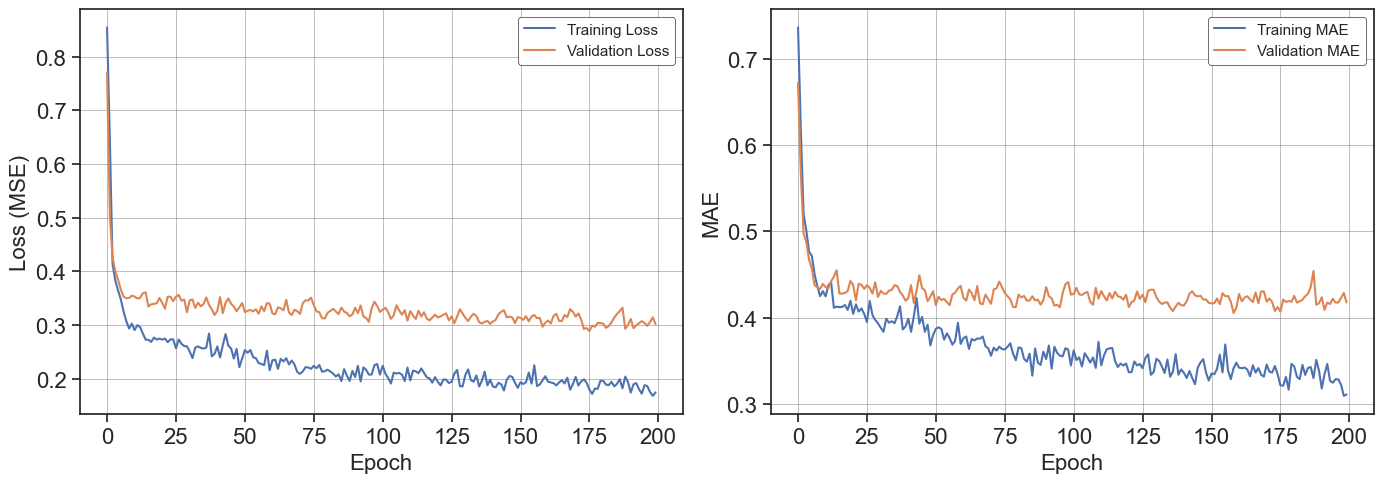

In [114]:
# Executing the function
training_validation_history_plot(history)

### One run test - Model evaluation

##### Calculating the predicted yield

In [115]:
# Prediction of training set
Y_train_pre_scaled = model.predict(X_train_processed)
Y_train_pred = Y_scaler.inverse_transform(Y_train_pre_scaled).flatten()

# Prediction of the yield value from the testing set based on the trained model. X_test is already scaled. And the Y_test_pred gets inverse scaled to get a yield value between 0-100%
Y_test_pred_scaled = model.predict(X_test_processed)
Y_test_pred = Y_scaler.inverse_transform(Y_test_pred_scaled).flatten()

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


##### Performance metrics

In [116]:
performance_metrics(Y_train, Y_train_pred, Y_test, Y_test_pred)


Performance metrics on the training set:
R² Score: 0.8208
MSE:      123.58
RMSE:     11.12%
MAE:      8.24%

Performance metrics on testing set:
R² Score: 0.7282
MSE:      190.34
RMSE:     13.80%
MAE:      10.93%


(123.5776327485623,
 np.float64(11.116547699198808),
 np.float64(8.23811056016451),
 0.8208432294260828,
 190.33573203716935,
 np.float64(13.79622165801816),
 np.float64(10.934719810907824),
 0.7281582067014676)

##### Performance visualization

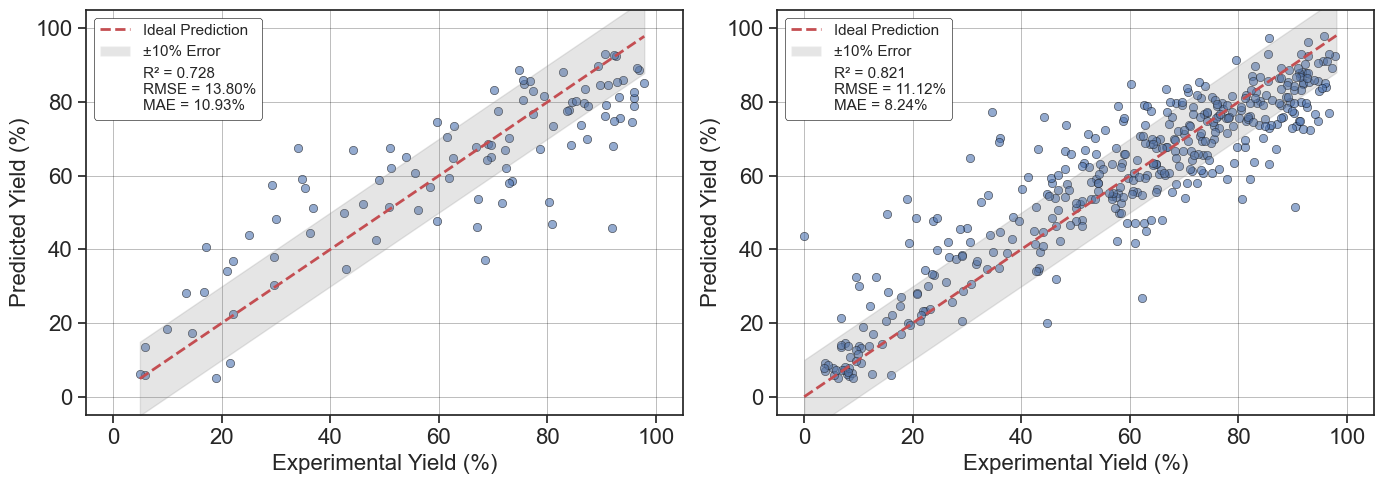

In [117]:
parity_plot(Y_train, Y_train_pred, Y_test, Y_test_pred)

In [ ]:
residual_analysis(Y_test, Y_test_pred)

### Final model - Hyperparameter optimization using Optuna

In [32]:
# Defining the objecive function
def nn_objective(trial):
    # Defining the parameter range over which the optimization is performed. Int are continuous, and categorical not
    # Model architecture parameters
    n_layers = trial.suggest_int('n_layers', 1, 4)
    units_per_layer = [trial.suggest_int(f'units_l{i}', 32, 512, log=True) # Where units represent the # Nodes
                       for i in range(n_layers)]
    dropout_rate = trial.suggest_float('dropout_rate', 0.0, 0.5)
    l2_reg = trial.suggest_float('l2_reg', 1e-4, 1e-2, log=True)

    # Training parameters
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])

    # 5-fold cross validation for this trial. Here, the cross validations is explicitly defined again, because the hyperparameters change don't allow for predefined functions to be called
    cv = KFold(n_splits=5, shuffle=True, random_state=random_number_seed)
    fold_mse_scores = []

    # Iterating over the different folds
    for train_idx, val_idx in cv.split(X_train):
        X_fold_train_raw, X_fold_val_raw = X_train.iloc[train_idx], X_train.iloc[val_idx]
        Y_fold_train_raw, Y_fold_val_raw = Y_train[train_idx], Y_train[val_idx]

        # Split training data further for early stopping
        X_inner_train_raw, X_inner_val_raw, Y_inner_train_raw, Y_inner_val_raw = train_test_split(
            X_fold_train_raw, Y_fold_train_raw, 
            test_size=0.2, 
            random_state=random_number_seed
        )

        # Preprocessing
        fold_preprocessor = ColumnTransformer(
            transformers=[('num', StandardScaler(), numerical_cols)]
        )
        X_inner_train = fold_preprocessor.fit_transform(X_inner_train_raw)
        X_inner_val = fold_preprocessor.transform(X_inner_val_raw)
        X_fold_val = fold_preprocessor.transform(X_fold_val_raw)

        # Scale Y (fit on inner training data only)
        fold_Y_scaler = StandardScaler()
        Y_inner_train = fold_Y_scaler.fit_transform(Y_inner_train_raw.reshape(-1, 1)).flatten()
        Y_inner_val = fold_Y_scaler.transform(Y_inner_val_raw.reshape(-1, 1)).flatten()
                
        # Build the NN model for this fold in this trial
        fold_model = keras.Sequential()
        fold_model.add(keras.layers.Input(shape=(X_inner_train.shape[1],)))
        for units in units_per_layer:
            fold_model.add(keras.layers.Dense(
                units, activation='relu',
                kernel_regularizer=regularizers.l2(l2_reg)
            ))
            fold_model.add(keras.layers.Dropout(dropout_rate))
        fold_model.add(keras.layers.Dense(1, activation='linear'))

        fold_model.compile(
            optimizer=Adam(learning_rate=learning_rate),
            loss='mse',
            metrics=['mae']
        )
        
        fold_early_stop = EarlyStopping(
            monitor='val_loss', patience=50,
            restore_best_weights=True, verbose=0
        )
        fold_reduce_lr = ReduceLROnPlateau(
            monitor='val_loss', factor=0.75,
            patience=20, min_lr=1e-5, verbose=0
        )
        # Training the fold model
        fold_model.fit(
            X_inner_train, Y_inner_train,
            validation_data=(X_inner_val, Y_inner_val), # On inner validation set for early stopping
            epochs=200, batch_size=batch_size,
            callbacks=[fold_early_stop, fold_reduce_lr],
            verbose=0
        )

        fold_val_pred_scaled = fold_model.predict(X_fold_val, verbose=0)
        fold_val_pred_original = fold_Y_scaler.inverse_transform(
            fold_val_pred_scaled.reshape(-1, 1)
        ).flatten()

        fold_mse = mean_squared_error(Y_fold_val_raw, fold_val_pred_original)
        fold_mse_scores.append(fold_mse)

    return np.mean(fold_mse_scores)
        

In [52]:
# Running the Optuna study
start_nn_optuna = time.time()

study_nn = optuna.create_study(
    direction='minimize', sampler=optuna.samplers.TPESampler(seed=random_number_seed)
    )
study_nn.optimize(nn_objective, n_trials=60, show_progress_bar=True)

end_nn_optuna = time.time()

best_params_nn = study_nn.best_params

print(f"\nOptuna NN search completed in {(end_nn_optuna - start_nn_optuna)/60:.1f} minutes")
print(f"Number of finished trials: {len(study_nn.trials)}")
print(f"Best parameters:\n{print(best_params_nn)}")
print(f"Best CV MSE (yield space): {study_nn.best_value:.4f}")

[I 2026-05-05 10:09:45,396] A new study created in memory with name: no-name-ad47d270-cb7b-477b-888f-160fe8fda130


  0%|          | 0/60 [00:00<?, ?it/s]

[I 2026-05-05 10:11:14,070] Trial 0 finished with value: 223.5593972528991 and parameters: {'n_layers': 2, 'units_l0': 447, 'units_l1': 243, 'dropout_rate': 0.2993292420985183, 'l2_reg': 0.0002051338263087451, 'learning_rate': 0.00020511104188433984, 'batch_size': 32}. Best is trial 0 with value: 223.5593972528991.
[I 2026-05-05 10:13:06,687] Trial 1 finished with value: 234.8852628678489 and parameters: {'n_layers': 3, 'units_l0': 33, 'units_l1': 471, 'units_l2': 321, 'dropout_rate': 0.10616955533913808, 'l2_reg': 0.0002310201887845295, 'learning_rate': 0.00023270677083837802, 'batch_size': 32}. Best is trial 0 with value: 223.5593972528991.
[I 2026-05-05 10:14:17,730] Trial 2 finished with value: 229.51604512683858 and parameters: {'n_layers': 2, 'units_l0': 174, 'units_l1': 46, 'dropout_rate': 0.14607232426760908, 'l2_reg': 0.0005404103854647331, 'learning_rate': 0.000816845589476017, 'batch_size': 16}. Best is trial 0 with value: 223.5593972528991.
[I 2026-05-05 10:15:40,073] Trial

In [ ]:
# import joblib
# # Save the Optuna study
# joblib.dump(study_nn, "BSL1-PER-NN-FINAL.pkl")
# # Best model: BSL1-PER-NN-FINAL

['BSL1-PER-VS2.pkl']

In [ ]:
# # To not run the whole Optuna study again
# import joblib
# # Load the Optuna study
# study_nn = joblib.load("BSL1-PER-NN-FINAL.pkl")
# print(f"Loaded Optuna study with {len(study_nn.trials)} trials")
# best_params_nn = study_nn.best_params
# print(f"Best parameters from loaded study:\n{print(best_params_nn)}")   

Loaded Optuna study with 30 trials
{'n_layers': 1, 'units_l0': 213, 'dropout_rate': 0.29852233751971996, 'l2_reg': 0.0005185911300112422, 'learning_rate': 0.004613714367127887, 'batch_size': 64}
Best parameters from loaded study:
None


In [138]:
optuna.visualization.plot_optimization_history(study_nn)

In [139]:
optuna.visualization.plot_parallel_coordinate(study_nn)

In [140]:
optuna.visualization.plot_param_importances(study_nn)

### Final model - Evaluation on Optuna model

In [15]:
def create_best_nn_model(input_dim, params):
    n_layers = params['n_layers']
    units_per_layer = [params[f'units_l{i}'] for i in range(n_layers)]
    dropout_rate = params['dropout_rate']
    l2_reg = params['l2_reg']
    learning_rate = params['learning_rate']

    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(input_dim,)))
    for units in units_per_layer:
        model.add(keras.layers.Dense(
            units, activation='relu',
            kernel_regularizer=regularizers.l2(l2_reg)
        ))
        model.add(keras.layers.Dropout(dropout_rate))
    model.add(keras.layers.Dense(1, activation='linear'))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae'] 
    )
    return model

In [16]:
print(best_params_nn)

{'n_layers': 1, 'units_l0': 213, 'dropout_rate': 0.29852233751971996, 'l2_reg': 0.0005185911300112422, 'learning_rate': 0.004613714367127887, 'batch_size': 64}


In [17]:
best_batch_size = best_params_nn['batch_size']

start_best_nn = time.time()

nn_best_model = create_best_nn_model(X_train_processed.shape[1], best_params_nn)
nn_best_model.summary()

best_early_stop = EarlyStopping(
    monitor='val_loss', patience=50,
    restore_best_weights=True, verbose=1
)
best_reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.75,
    patience=20, min_lr=1e-5, verbose=1
)

history_best = nn_best_model.fit(
    X_train_processed, Y_train_scaled,
    validation_split=0.2,
    epochs=200, batch_size=best_batch_size,
    callbacks=[best_early_stop, best_reduce_lr],
    verbose=1, shuffle=True
)

end_best_nn = time.time()
print(f"\nBest model training time: {end_best_nn - start_best_nn:.2f}s")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 213)            │         4,260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 213)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           214 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,474 (17.48 KB)

 Trainable params: 4,474 (17.48 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - loss: 0.8749 - mae: 0.7473 - val_loss: 0.6455 - val_mae: 0.6559 - learning_rate: 0.0046
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.6577 - mae: 0.6295 - val_loss: 0.5091 - val_mae: 0.5630 - learning_rate: 0.0046
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.4338 - mae: 0.5199 - val_loss: 0.4522 - val_mae: 0.5183 - learning_rate: 0.0046
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.4254 - mae: 0.5181 - val_loss: 0.3909 - val_mae: 0.4671 - learning_rate: 0.0046
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.3624 - mae: 0.4737 - val_loss: 0.3797 - val_mae: 0.4588 - learning_rate: 0.0046
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.3648 - mae: 0.4662 - val_loss: 0.3581 - val_mae: 0.4447 - learning_rate: 0.0046
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3265 - mae: 0.4498 - val_loss: 0.3559 - val_mae: 0.4461 - learning_rate: 0.0046
Epoch 8/200
6/6 ━━━━

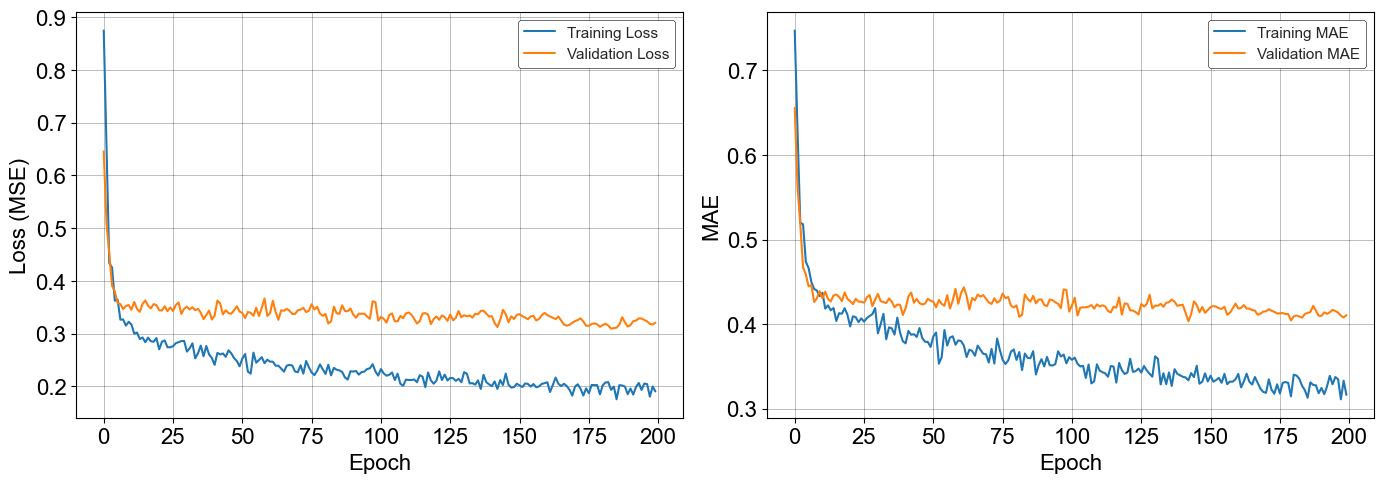

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Best NN model for a single run performance:

Performance metrics on the training set:
R² Score: 0.8187
MSE:      125.03
RMSE:     11.18%
MAE:      8.28%

Performance metrics on testing set:
R² Score: 0.7268
MSE:      191.31
RMSE:     13.83%
MAE:      10.97%


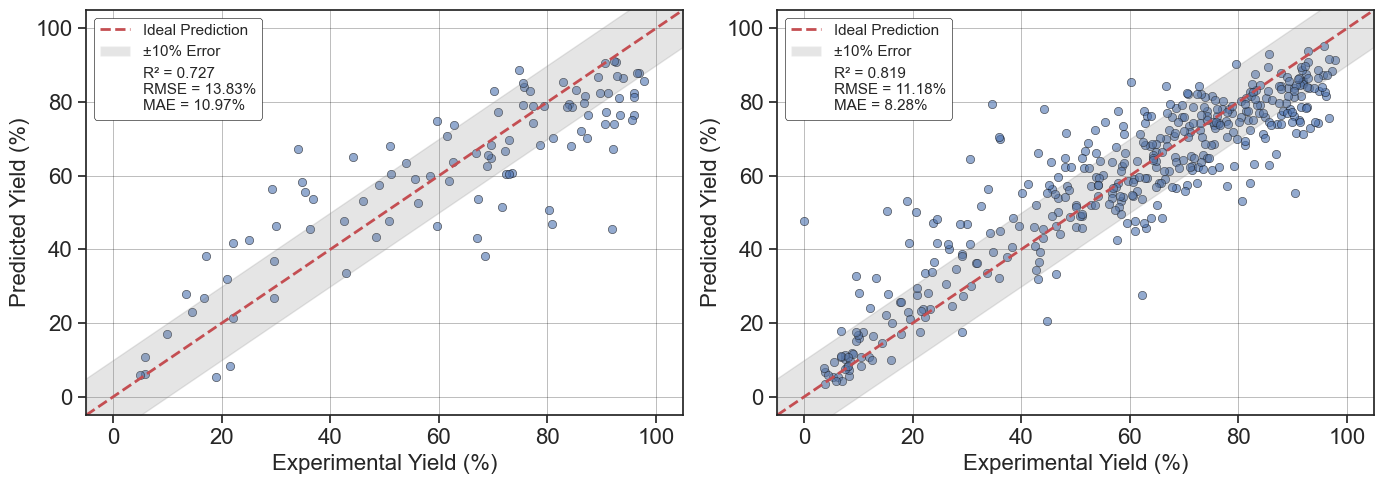

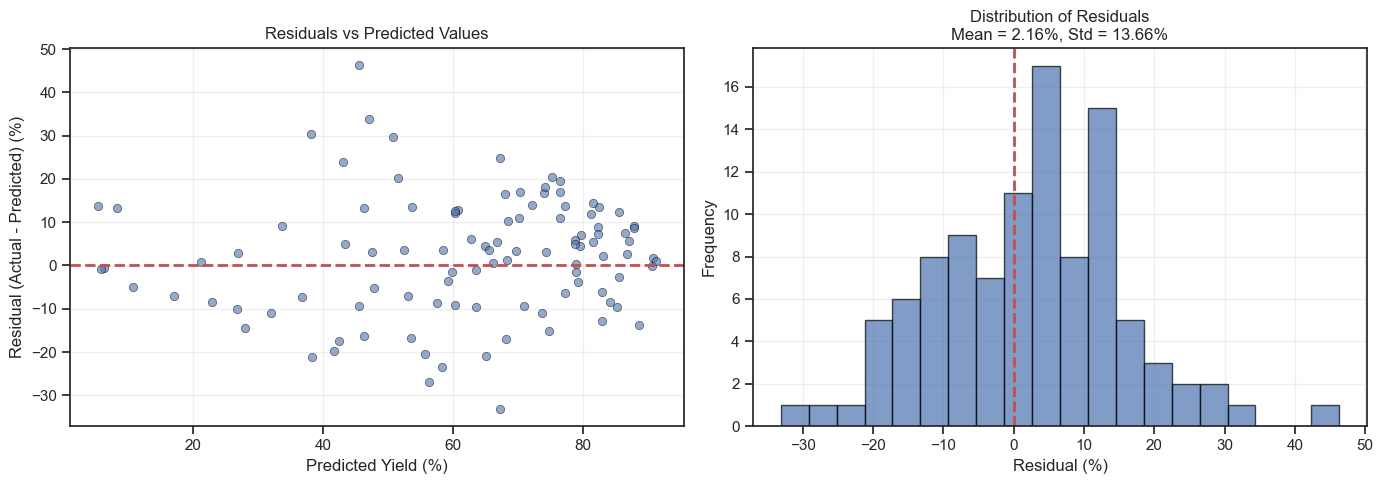

In [18]:
# Training history
training_validation_history_plot(history_best)

# Predication for the train and test set
Y_train_best_nn_pred = Y_scaler.inverse_transform(
    nn_best_model.predict(X_train_processed)).flatten()
Y_test_best_nn_pred  = Y_scaler.inverse_transform(
    nn_best_model.predict(X_test_processed)).flatten()

# Performance metrics
print("Best NN model for a single run performance:")
performance_metrics(Y_train, Y_train_best_nn_pred, Y_test, Y_test_best_nn_pred)

# Parity plot
parity_plot(Y_train, Y_train_best_nn_pred, Y_test, Y_test_best_nn_pred)

# Residual analysis
residual_analysis(Y_test, Y_test_best_nn_pred)

#### Cross validation of the Optuna best model

In [129]:
def run_cross_validation_best_nn(X, Y, params, n_splits=5,
                                  random_state=random_number_seed):
    
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    mae_per_fold_test,  mae_per_fold_train, rmse_per_fold_train  = [], [], []
    r2_per_fold_test,   r2_per_fold_train, rmse_per_fold_test   = [], [], []

    n_layers     = params['n_layers']
    batch_size   = params['batch_size']

    for fold_no, (train_idx, test_idx) in enumerate(cv.split(X, Y), start=1):
        print(f'Training for fold {fold_no}/{n_splits}')

        train_X_raw_unsp = X.iloc[train_idx] # unsp: unsplit data
        test_X_raw_unsp = X.iloc[test_idx] # raw: not transformed or processed
        train_Y_raw_unsp = Y[train_idx]
        test_Y_raw_unsp = Y[test_idx]

        # This replaces validation_split=0.2 inside model.fit(). And is better because other takes last 20% of data
        train_X_raw, val_X_raw, train_Y_raw, val_Y_raw = train_test_split(
            train_X_raw_unsp, train_Y_raw_unsp, test_size=0.2, random_state=random_state
        )

        # Preprocessing — fit inside fold to avoid data leakage
        fold_preprocessor = ColumnTransformer(
            transformers=[('num', StandardScaler(), numerical_cols)])
        
        train_X = fold_preprocessor.fit_transform(train_X_raw)
        val_X   = fold_preprocessor.transform(val_X_raw)  
        test_X  = fold_preprocessor.transform(test_X_raw_unsp)

        # Scale Y — also fit only on inner training data
        fold_Y_scaler = StandardScaler()
        train_Y = fold_Y_scaler.fit_transform(train_Y_raw.reshape(-1, 1)).flatten()
        val_Y   = fold_Y_scaler.transform(val_Y_raw.reshape(-1, 1)).flatten()

        # Build & train
        fold_model = create_best_nn_model(train_X.shape[1], params)
        fold_early_stop = EarlyStopping(monitor='val_loss', patience=50,
                                restore_best_weights=True, verbose=1)
        fold_reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.75,
                                    patience=20, min_lr=1e-5, verbose=1)

        history_fold = fold_model.fit(
            train_X, train_Y,
            validation_data=(val_X, val_Y), epochs=200, batch_size=batch_size,
            callbacks=[fold_early_stop, fold_reduce_lr], verbose=1, shuffle=True
        )

        # Inverse-scale predictions
        test_pred  = fold_Y_scaler.inverse_transform(
                         fold_model.predict(test_X,  verbose=0)).flatten()
        train_pred = fold_Y_scaler.inverse_transform(
                         fold_model.predict(train_X, verbose=0)).flatten()

        mae_test  = np.mean(np.abs(test_pred  - test_Y_raw_unsp))
        mae_train = np.mean(np.abs(train_pred - train_Y_raw))
        
        r2_test   = r2_score(test_Y_raw_unsp, test_pred)
        r2_train  = r2_score(train_Y_raw, train_pred)

        rmse_test = np.sqrt(mean_squared_error(test_Y_raw_unsp, test_pred))
        rmse_train = np.sqrt(mean_squared_error(train_Y_raw, train_pred))

        mae_per_fold_test.append(mae_test);  mae_per_fold_train.append(mae_train)
        r2_per_fold_test.append(r2_test);    r2_per_fold_train.append(r2_train)
        rmse_per_fold_test.append(rmse_test);  rmse_per_fold_train.append(rmse_train)

        print(f"Test  R² = {r2_test:.3f}  |  MAE = {mae_test:.2f}% |  RMSE = {rmse_test:.2f}%")
        print(f"Train R² = {r2_train:.3f}  |  MAE = {mae_train:.2f}% |  RMSE = {rmse_train:.2f}%")

        # Parity plot per fold
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        for ax, actual, predicted, label, r2v, maev in [
            (axes[0], test_Y_raw_unsp,  test_pred,  'Test',  r2_test,  mae_test),
            (axes[1], train_Y_raw, train_pred, 'Train', r2_train, mae_train),
        ]:
            ax.scatter(actual, predicted, alpha=0.6, edgecolors='black', linewidth=0.5)
            lo, hi = min(actual.min(), predicted.min()), max(actual.max(), predicted.max())
            ax.plot([lo, hi], [lo, hi], 'r--', linewidth=2, label='Ideal')
            ax.set_xlabel('Experimental Yield (%)', fontsize=12)
            ax.set_ylabel('Predicted Yield (%)',    fontsize=12)
            ax.set_title(
                f'Parity Plot – {label} Set  |  Fold {fold_no}\n'
                f'R² = {r2v:.3f},  MAE = {maev:.2f}%', fontsize=12)
            ax.legend(); ax.grid(True, alpha=0.3)
            ax.set_xlim(-10, 110); ax.set_ylim(-10, 110)
        plt.tight_layout(); plt.show()

        # Training / validation loss per fold
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        axes[0].plot(history_fold.history['loss'],     label='Train Loss')
        axes[0].plot(history_fold.history['val_loss'], label='Val Loss')
        axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss (MSE)')
        axes[0].set_title(f'Loss – Fold {fold_no}')
        axes[0].legend(); axes[0].grid(True, alpha=0.3)

        axes[1].plot(history_fold.history['mae'],     label='Train MAE')
        axes[1].plot(history_fold.history['val_mae'], label='Val MAE')
        axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE')
        axes[1].set_title(f'MAE – Fold {fold_no}')
        axes[1].legend(); axes[1].grid(True, alpha=0.3)
        plt.tight_layout(); plt.show()

    return r2_per_fold_test, r2_per_fold_train, mae_per_fold_test, mae_per_fold_train, rmse_per_fold_test, rmse_per_fold_train

Training for fold 1/5
Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.7223 - mae: 0.6790 - val_loss: 0.4753 - val_mae: 0.5444 - learning_rate: 0.0046
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.5115 - mae: 0.5662 - val_loss: 0.4772 - val_mae: 0.5668 - learning_rate: 0.0046
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.4810 - mae: 0.5509 - val_loss: 0.4420 - val_mae: 0.5462 - learning_rate: 0.0046
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.4190 - mae: 0.5105 - val_loss: 0.3655 - val_mae: 0.4792 - learning_rate: 0.0046
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.3879 - mae: 0.4834 - val_loss: 0.3677 - val_mae: 0.4802 - learning_rate: 0.0046
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.3714 - mae: 0.4708 - val_loss: 0.3715 - val_mae: 0.4807 - learning_rate: 0.0046
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.3326 - mae: 0.4471 - val_loss: 0.3807 - val_mae: 0.4880 - learning_rate: 0.004

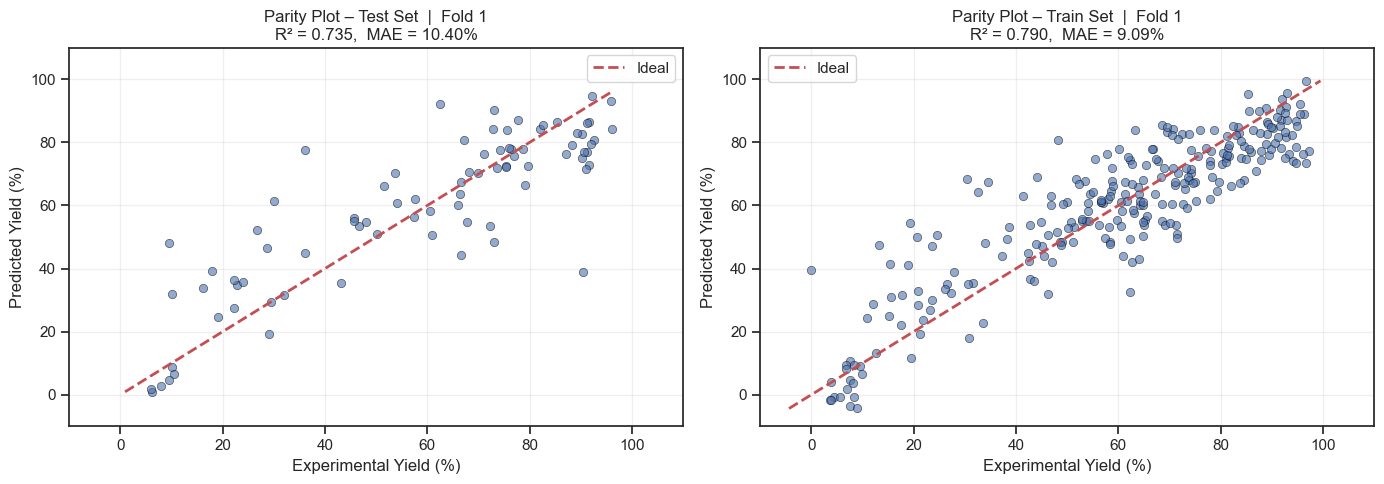

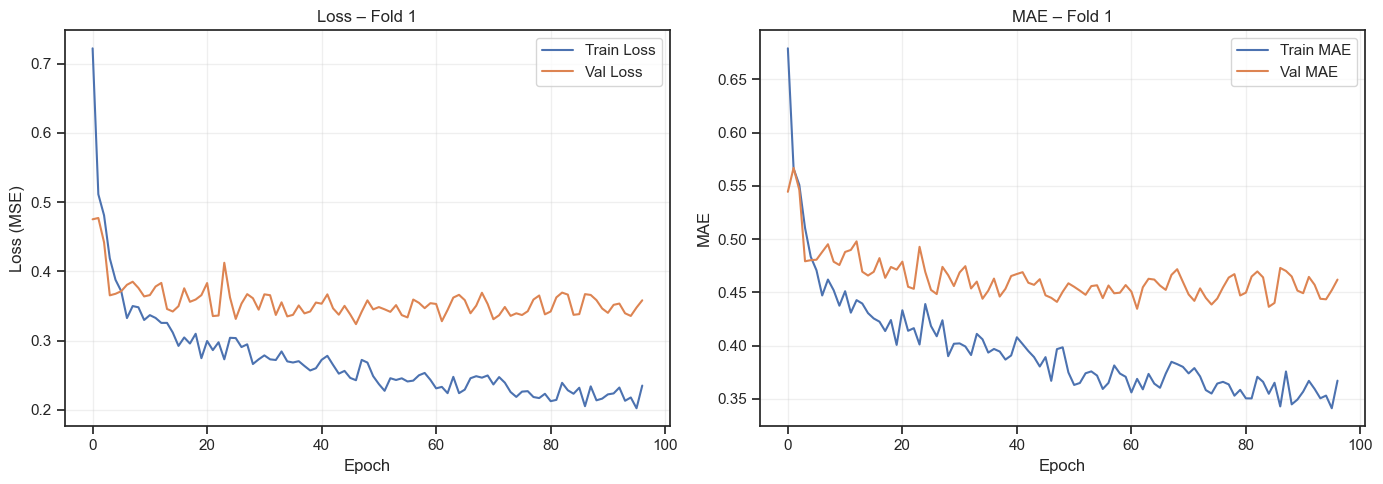

Training for fold 2/5
Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - loss: 0.8749 - mae: 0.7491 - val_loss: 0.5231 - val_mae: 0.5634 - learning_rate: 0.0046
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.6154 - mae: 0.6163 - val_loss: 0.4976 - val_mae: 0.5629 - learning_rate: 0.0046
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.4862 - mae: 0.5433 - val_loss: 0.4266 - val_mae: 0.4915 - learning_rate: 0.0046
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.4998 - mae: 0.5672 - val_loss: 0.3847 - val_mae: 0.4853 - learning_rate: 0.0046
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.4509 - mae: 0.5372 - val_loss: 0.3769 - val_mae: 0.4747 - learning_rate: 0.0046
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.4371 - mae: 0.5339 - val_loss: 0.3875 - val_mae: 0.4659 - learning_rate: 0.0046
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.3836 - mae: 0.4801 - val_loss: 0.3618 - val_mae: 0.4598 - learning_rate: 0.00

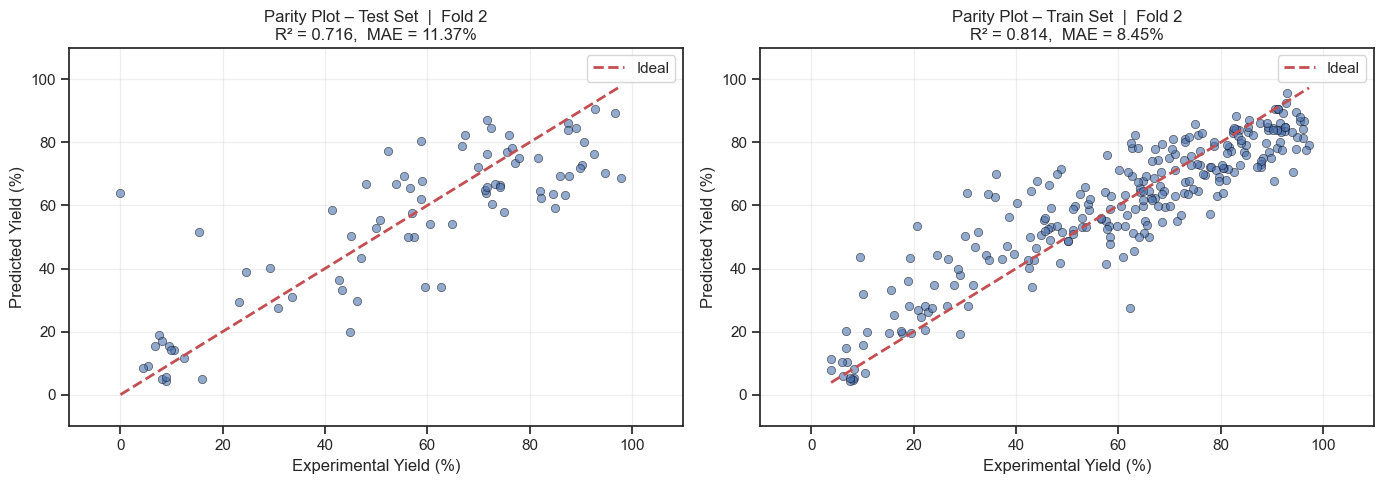

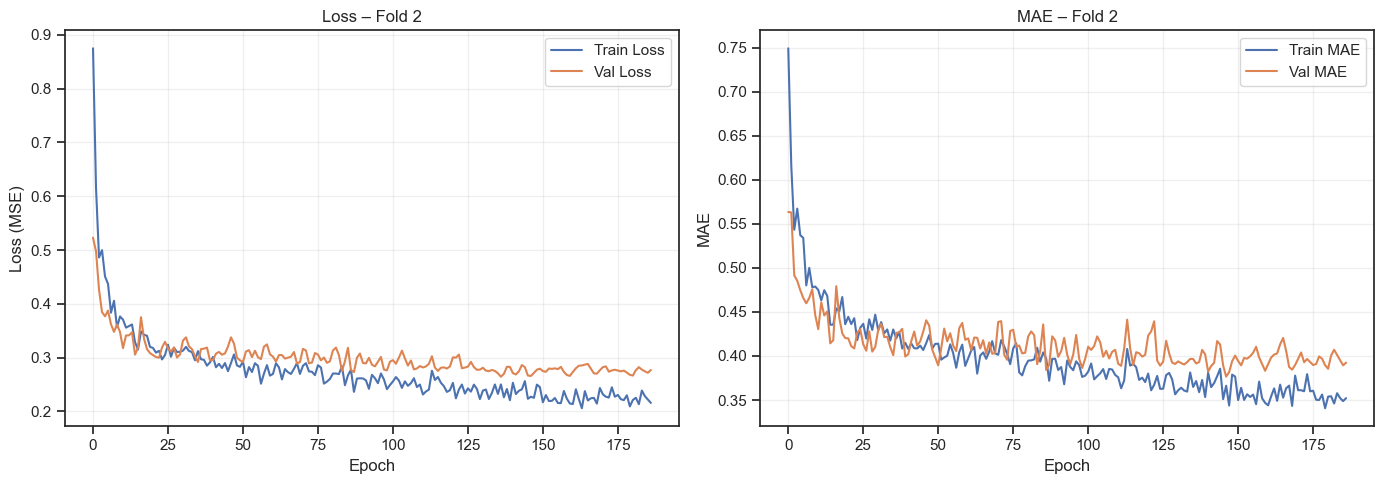

Training for fold 3/5
Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - loss: 0.7971 - mae: 0.7171 - val_loss: 0.5285 - val_mae: 0.5483 - learning_rate: 0.0046
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.6427 - mae: 0.6100 - val_loss: 0.3672 - val_mae: 0.4519 - learning_rate: 0.0046
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.4846 - mae: 0.5418 - val_loss: 0.3066 - val_mae: 0.4183 - learning_rate: 0.0046
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.4138 - mae: 0.5104 - val_loss: 0.2550 - val_mae: 0.3709 - learning_rate: 0.0046
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.3990 - mae: 0.4905 - val_loss: 0.2621 - val_mae: 0.3838 - learning_rate: 0.0046
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.3842 - mae: 0.4864 - val_loss: 0.2371 - val_mae: 0.3641 - learning_rate: 0.0046
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.3500 - mae: 0.4536 - val_loss: 0.2082 - val_mae: 0.3412 - learning_rate: 0.004

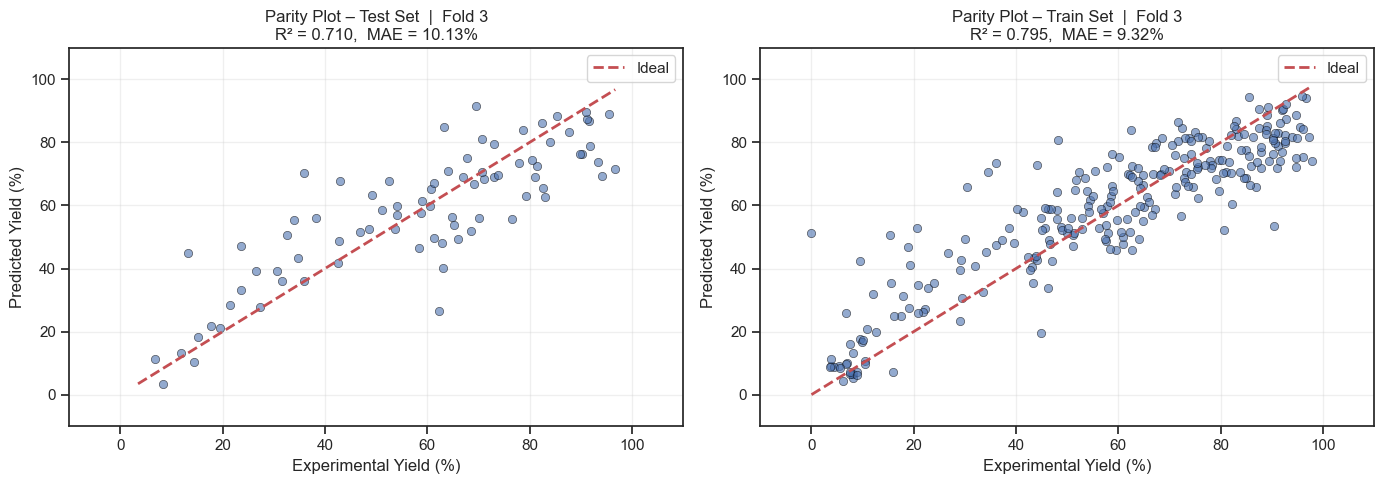

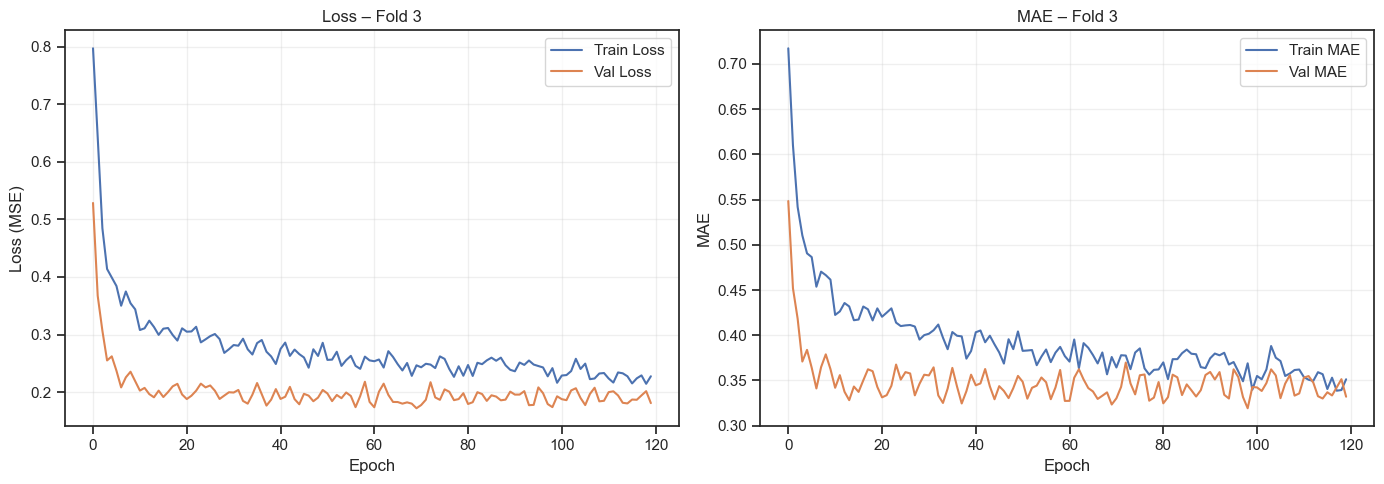

Training for fold 4/5
Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.8120 - mae: 0.7343 - val_loss: 0.6815 - val_mae: 0.6753 - learning_rate: 0.0046
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.5240 - mae: 0.5889 - val_loss: 0.5147 - val_mae: 0.5797 - learning_rate: 0.0046
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.4106 - mae: 0.5167 - val_loss: 0.5496 - val_mae: 0.6023 - learning_rate: 0.0046
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.4136 - mae: 0.5190 - val_loss: 0.4284 - val_mae: 0.5111 - learning_rate: 0.0046
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.3472 - mae: 0.4644 - val_loss: 0.4060 - val_mae: 0.4733 - learning_rate: 0.0046
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.3323 - mae: 0.4510 - val_loss: 0.4244 - val_mae: 0.4917 - learning_rate: 0.0046
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.3272 - mae: 0.4439 - val_loss: 0.4430 - val_mae: 0.5064 - learning_rate: 0.004

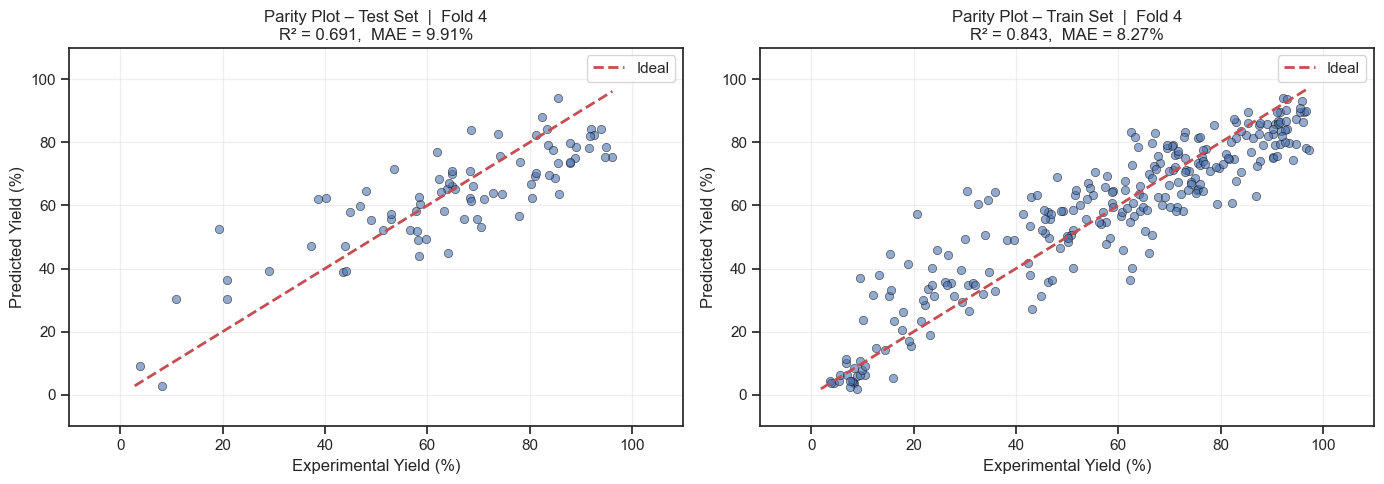

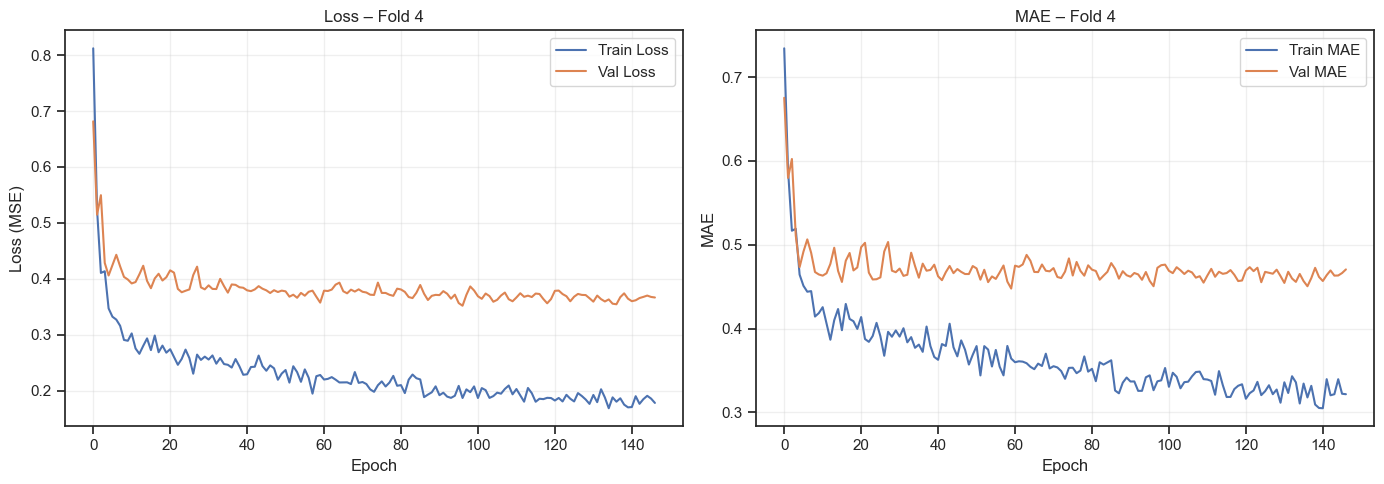

Training for fold 5/5
Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - loss: 0.8430 - mae: 0.7461 - val_loss: 0.5299 - val_mae: 0.5685 - learning_rate: 0.0046
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.5691 - mae: 0.6057 - val_loss: 0.3972 - val_mae: 0.5085 - learning_rate: 0.0046
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.4724 - mae: 0.5386 - val_loss: 0.3563 - val_mae: 0.4738 - learning_rate: 0.0046
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.3901 - mae: 0.4812 - val_loss: 0.3432 - val_mae: 0.4581 - learning_rate: 0.0046
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.3979 - mae: 0.4940 - val_loss: 0.3398 - val_mae: 0.4681 - learning_rate: 0.0046
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.3582 - mae: 0.4704 - val_loss: 0.3115 - val_mae: 0.4423 - learning_rate: 0.0046
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.3738 - mae: 0.4766 - val_loss: 0.3111 - val_mae: 0.4334 - learning_rate: 0.004

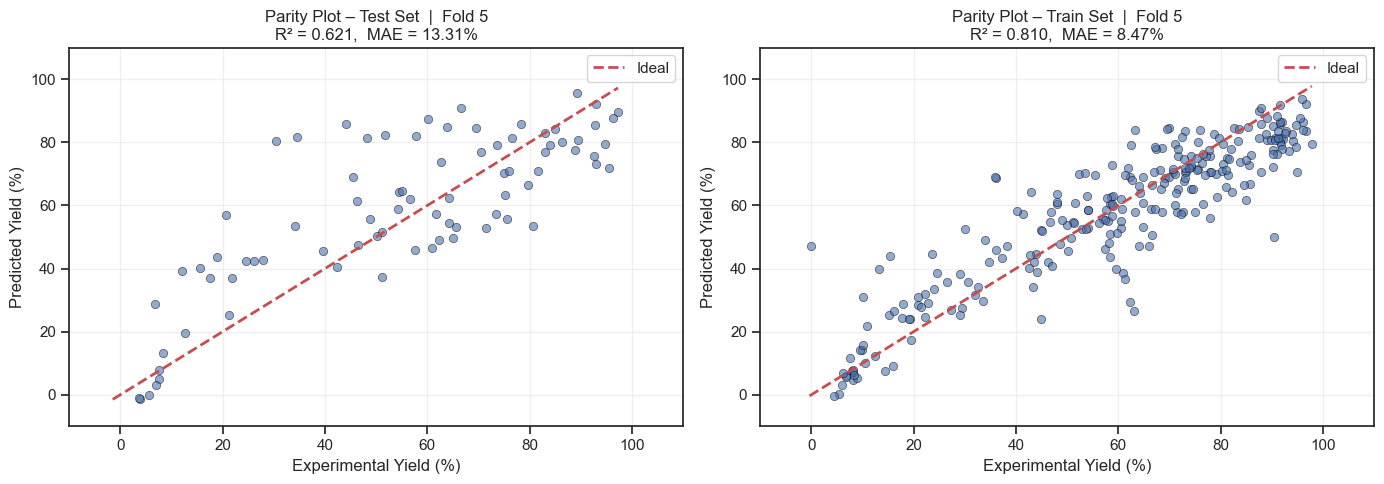

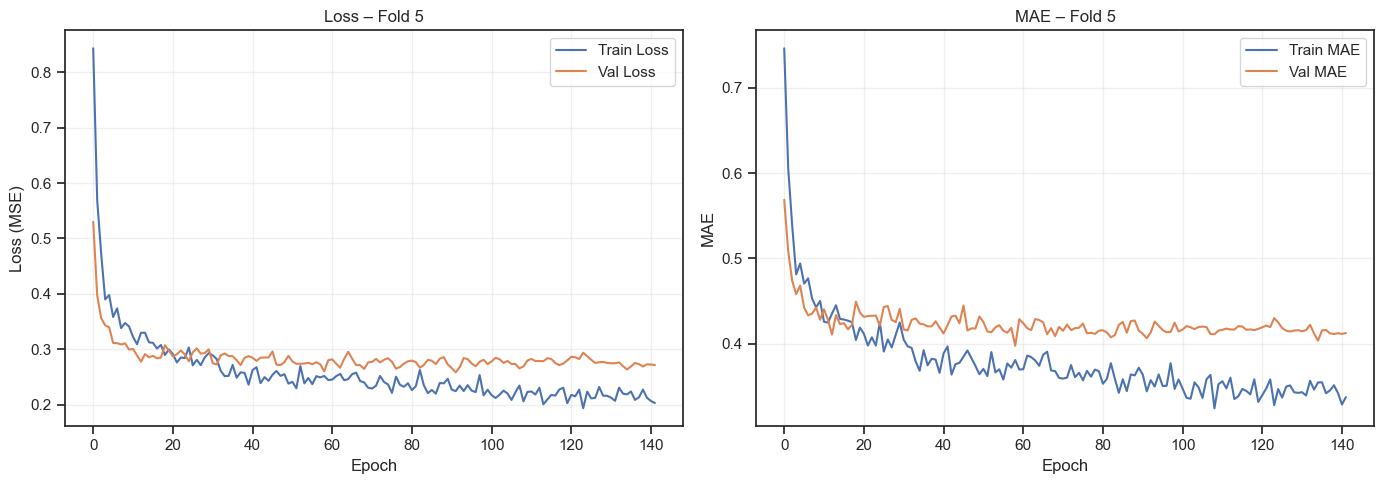


Best NN — 5-fold CV results (test):
MAE: 11.03% ± 1.25%
R²:  69.47% ± 3.918%
RMSE: 14.29% ± 1.75%

Best NN — 5-fold CV results (train):
MAE: 8.72% ± 0.41%
R²:  81.03% ± 1.878%
RMSE: 11.41% ± 0.57%


In [130]:
r2_test_best, r2_train_best, mae_test_best, mae_train_best, rmse_test_best, rmse_train_best = \
    run_cross_validation_best_nn(X_train, Y_train, best_params_nn, n_splits=5)

print(f'\nBest NN — 5-fold CV results (test):')
print(f'MAE: {np.mean(mae_test_best):.2f}% ± {np.std(mae_test_best):.2f}%')
print(f'R²:  {np.mean(r2_test_best)*100:.2f}% ± {np.std(r2_test_best)*100:.3f}%')
print(f'RMSE: {np.mean(rmse_test_best):.2f}% ± {np.std(rmse_test_best):.2f}%')

print(f'\nBest NN — 5-fold CV results (train):')
print(f'MAE: {np.mean(mae_train_best):.2f}% ± {np.std(mae_train_best):.2f}%')
print(f'R²:  {np.mean(r2_train_best)*100:.2f}% ± {np.std(r2_train_best)*100:.3f}%')
print(f'RMSE: {np.mean(rmse_train_best):.2f}% ± {np.std(rmse_train_best):.2f}%')

#### SHAP-analysis of the Optuna best model

In [131]:
background = X_train_processed
explainer = shap.GradientExplainer(nn_best_model, background)
shap_values_raw = explainer.shap_values(X_test_processed)

# Handle both old SHAP (returns list) and new SHAP (returns array directly)
if isinstance(shap_values_raw, list):
    shap_vals = shap_values_raw[0]   # old: list of arrays, one per output
else:
    shap_vals = shap_values_raw      # new: array directly, shape (n_samples, n_features)

# Squeeze in case of shape (n_samples, n_features, 1)
if shap_vals.ndim == 3:
    shap_vals = shap_vals[:, :, 0]

print(f"SHAP values shape: {shap_vals.shape}")         # should be (n_test, n_features)
print(f"X_test_processed shape: {X_test_processed.shape}")  # should match

c:\Users\livio\anaconda3\envs\ML_ENVIRONEMENT\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_6498
Received: inputs=['Tensor(shape=(103, 19))']
  warnings.warn(msg)
c:\Users\livio\anaconda3\envs\ML_ENVIRONEMENT\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_6498
Received: inputs=['Tensor(shape=(50, 19))']
  warnings.warn(msg)


SHAP values shape: (103, 19)
X_test_processed shape: (103, 19)


In [1]:
shap.summary_plot(shap_vals, X_test_processed, feature_names=feature_names, plot_type='bar', show=True)

NameError: name 'shap' is not defined

C:\Users\livio\AppData\Local\Temp\ipykernel_228704\3680698320.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals, X_test_processed, feature_names=feature_names, show=True)


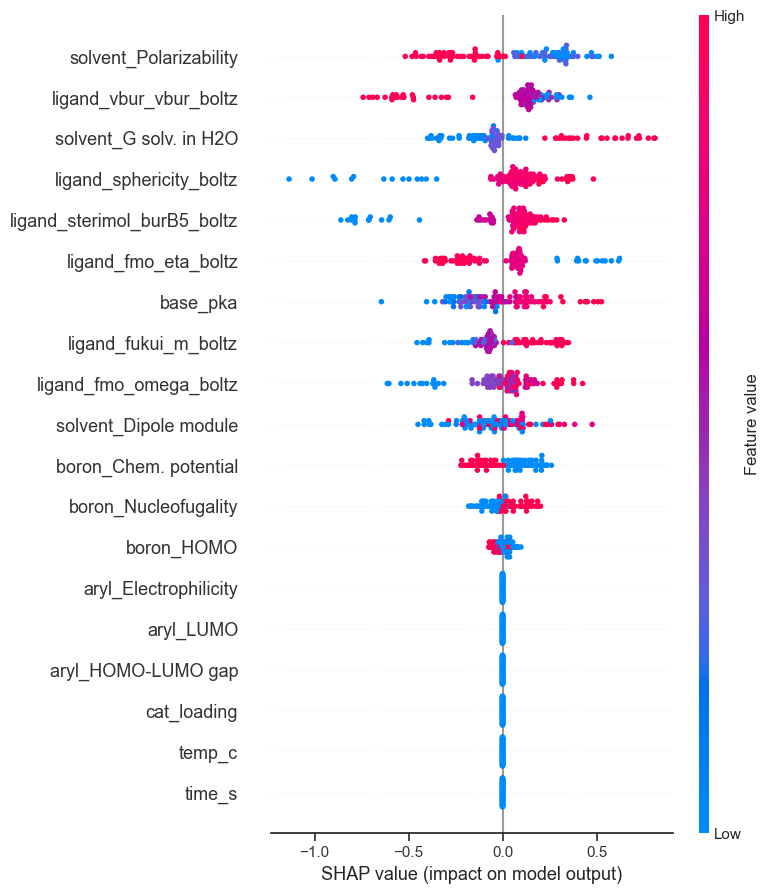

In [133]:
# Beeswarm plot
shap.summary_plot(shap_vals, X_test_processed, feature_names=feature_names, show=True)

In [134]:
# Tabular ranking
shap_importance = pd.DataFrame({
    'descriptor': feature_names,
    'mean_abs_shap': np.abs(shap_vals).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print(shap_importance)

                     descriptor  mean_abs_shap
11       solvent_Polarizability       0.257602
14       ligand_vbur_vbur_boltz       0.247529
10       solvent_G solv. in H2O       0.219487
13      ligand_sphericity_boltz       0.201230
15  ligand_sterimol_burB5_boltz       0.199093
16         ligand_fmo_eta_boltz       0.197039
12                     base_pka       0.172111
18         ligand_fukui_m_boltz       0.158279
17       ligand_fmo_omega_boltz       0.146843
9         solvent_Dipole module       0.141665
7         boron_Chem. potential       0.115600
8          boron_Nucleofugality       0.073352
6                    boron_HOMO       0.032648
0                        time_s       0.000000
1                        temp_c       0.000000
2                   cat_loading       0.000000
4                     aryl_LUMO       0.000000
5         aryl_Electrophilicity       0.000000
3            aryl_HOMO-LUMO gap       0.000000


##### Outlier analysis

In [21]:
results_check = pd.DataFrame({
    'y_true': Y_test,
    'y_pred': Y_test_best_nn_pred,
    'residual': Y_test - Y_test_best_nn_pred,
    'abs_residual': np.abs(Y_test - Y_test_best_nn_pred),
    'ligand' : df_test['catalyst'],
    'time': df_test['time_s'],
    'temperautre': df_test['temp_c'],
    'cat loading': df_test['cat_loading'],
    'aryl halide': df_test['name_aryl_halide'],
    'boron species': df_test['name_boron_species'],
    'solvent': df_test['name_solvent'],
    'base': df_test['name_base']
}, index=X_test.index)

# Find outliers
outliers = results_check.nlargest(10, 'abs_residual')
# # Look them up in the orginal dataframe
# original_df.loc[outliers.index]

import plotly.express as px
import plotly.graph_objects as go

results_check['original_index'] = results_check.index
fig = px.scatter(results_check, x='y_true', y='y_pred', hover_data=['original_index', 'residual'], title='Predicted vs Actual Yields with Residuals')
fig.add_shape(type='line', x0=0, y0=0, x1=100, y1=100, line=dict(color='Red', dash='dash'))
fig.show()

print(outliers)

        y_true     y_pred   residual  abs_residual       ligand  time  \
304  91.871973  45.548183  46.323790     46.323790      P(tBu)3    60   
440  80.941131  47.026978  33.914153     33.914153      P(tBu)3    60   
30   34.032527  67.184219 -33.151693     33.151693        XPhos    60   
184  68.498529  38.084728  30.413801     30.413801      P(tBu)3    60   
148  80.362498  50.759068  29.603430     29.603430  CataCXium A    60   
247  29.257479  56.266254 -27.008776     27.008776            0    60   
296  92.064673  67.177658  24.887015     24.887015      P(tBu)3    60   
176  66.966870  43.042259  23.924610     23.924610      P(tBu)3    60   
93   34.879592  58.370495 -23.490903     23.490903        SPhos    60   
502  17.110177  38.324551 -21.214373     21.214373        XPhos    60   

     temperautre  cat loading       aryl halide  \
304          100         6.25  6-bromoquinoline   
440          100         6.25  6-bromoquinoline   
30           100         6.25  6-bromoquino

In [23]:
results_check['original_index'] = results_check.index
outlier_indices = outliers.index

fig = px.scatter(
    results_check,
    x='y_true',
    y='y_pred',
    color='ligand',                  # <-- color by ligand
    hover_data={
        'original_index': True,
        'residual': ':.2f',
        'ligand': True,
        'aryl halide': True,
        'boron species': True,
        'time': True,
        'temperautre': True,
        'cat loading': True,
        'solvent': True,
        'base': True
    },
    title='Predicted vs Actual Yields — colored by ligand',
    opacity=0.7,
)

# Add dashed perfect-prediction line
fig.add_shape(
    type='line', x0=0, y0=0, x1=100, y1=100,
    line=dict(color='black', dash='dash', width=1)
)

# Overlay outlier ring markers
outlier_data = results_check.loc[outlier_indices]
fig.add_trace(go.Scatter(
    x=outlier_data['y_true'],
    y=outlier_data['y_pred'],
    mode='markers+text',
    marker=dict(size=18, color='rgba(0,0,0,0)', line=dict(color='red', width=2)),
    text=outlier_data.index.astype(str),
    textposition='top center',
    textfont=dict(size=10, color='red'),
    name='Top 10 outliers',
    hoverinfo='skip',               # avoids double tooltip
))

fig.update_layout(
    xaxis_title='Actual yield (%)',
    yaxis_title='Predicted yield (%)',
    legend_title='Ligand',
    width=800, height=600,
)
fig.show()